In [ ]:
#scraper that addresses party change FINAL WORKING SCRAPER 2004-2009
import requests
from bs4 import BeautifulSoup
import csv
import os

# URL of the MEP directory
directory_url = "https://www.europarl.europa.eu/meps/en/directory/9"

# Directory to save the CSV file
output_directory = 

# Output CSV file path
output_file = os.path.join(output_directory, "raw_mep_data_CRE-9.csv")

print("Starting the web scraping process...")

# Make a request to the directory page
print(f"Fetching MEP directory page: {directory_url}")
response = requests.get(directory_url)
soup = BeautifulSoup(response.text, 'html.parser')

# Find all the links to individual MEPs
print("Finding links to individual MEPs...")
mep_links = soup.find_all('a', href=True)
mep_links = [link['href'] for link in mep_links if "/meps/en/" in link['href']]

print(f"Found {len(mep_links)} MEP links.")

# Prepare the CSV file
print(f"Preparing to write data to {output_file}")
with open(output_file, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['Name', 'Country', 'Party', 'Date'])

    for index, link in enumerate(mep_links):
        # If the link is already absolute, use it as is
        if link.startswith("https://"):
            mep_url = link
        else:
            # Otherwise, prepend the base URL
            mep_url = "https://www.europarl.europa.eu" + link

        print(f"Processing MEP {index + 1}/{len(mep_links)}: {mep_url}")

        try:
            mep_response = requests.get(mep_url)
            mep_response.raise_for_status()  # Raises HTTPError for bad responses
        except requests.exceptions.RequestException as e:
            print(f"Error accessing {mep_url}: {e}")
            continue

        mep_soup = BeautifulSoup(mep_response.text, 'html.parser')

        # Extract the MEP's name
        name_tag = mep_soup.find('span', class_='sln-member-name')
        name = name_tag.text.strip() if name_tag else "N/A"
        print(f"Extracted Name: {name}")

        # Extract the country
        country_tag = mep_soup.find('div', class_='erpl_title-h3 mt-1 mb-1')
        country = country_tag.text.strip() if country_tag else "N/A"
        print(f"Extracted Country: {country}")

        # Extract MEP ID and Name correctly from the original link
        mep_parts = link.split('/')
        
        # Extract MEP ID - Ensure there's a numeric part
        mep_id = None
        for part in mep_parts:
            if part.isdigit():
                mep_id = part
                break
        
        if not mep_id:
            print(f"Warning: No MEP ID found in URL {link}")
            continue  # Skip to the next MEP if no ID is found

        # Correctly format the MEP name for the fallback URL
        formatted_name = name.upper().replace(" ", "_")

        # Construct the correct URL to fetch party history
        detailed_url = f"https://www.europarl.europa.eu/meps/en/{mep_id}/{formatted_name}/history/9#detailedcardmep"
        print(f"Fetching detailed history page: {detailed_url}")

        try:
            detailed_response = requests.get(detailed_url)
            detailed_response.raise_for_status()  # Raises HTTPError for bad responses
            detailed_soup = BeautifulSoup(detailed_response.text, 'html.parser')

            # Find the div with class 'erpl_meps-status' where the political group changes are listed
            status_div = detailed_soup.find('div', class_='erpl_meps-status')
            if status_div:
                # Extract all strong tags and their associated texts within this section
                strong_tags = status_div.find_all('strong')
                for strong_tag in strong_tags:
                    date = strong_tag.text.strip()
                    party_info = strong_tag.find_next_sibling(text=True)
                    if party_info:
                        party = party_info.strip()
                        print(f"Extracted Party: {party}, Date: {date}")

                        # Write each party change as a separate row in the CSV file
                        writer.writerow([name, country, party, date])
                        print(f"Data for {name} with party {party} written to CSV.")

        except requests.exceptions.RequestException as e:
            print(f"Error accessing detailed history page {detailed_url}: {e}")

print(f"Data successfully saved to {output_file}")



In [13]:
#pre processing
import os
import pandas as pd

# Source and destination directories
source_dir = 
destination_dir = 

# List of European countries and their acronyms
country_to_acronym = {
    'Belgium': 'BE', 'Greece': 'EL', 'Lithuania': 'LT', 'Portugal': 'PT',
    'Bulgaria': 'BG', 'Spain': 'ES', 'Luxembourg': 'LU', 'Romania': 'RO',
    'Czechia': 'CZ', 'France': 'FR', 'Hungary': 'HU', 'Slovenia': 'SI',
    'Denmark': 'DK', 'Croatia': 'HR', 'Malta': 'MT', 'Slovakia': 'SK',
    'Germany': 'DE', 'Italy': 'IT', 'Netherlands': 'NL', 'Finland': 'FI',
    'Estonia': 'EE', 'Cyprus': 'CY', 'Austria': 'AT', 'Sweden': 'SE',
    'Ireland': 'IE', 'Latvia': 'LV', 'Poland': 'PL', 'United Kingdom': 'UK'
}

# Dictionary mapping group names to their acronyms
group_to_acronym = {
    'European People\'s Party–European Democrats': 'EPP-ED',
    'Group of the European People\'s Party (Christian Democrats) and European Democrats': 'EPP-ED',
    'Group of the European People\'s Party (Christian': 'EPP',
    'Party of European Socialists': 'PES',
    'Socialist Group in the European Parliament':'PES',
    'Alliance of Liberals and Democrats for Europe': 'ALDE',
    'Greens/European Free Alliance': 'G/EFA',
    'European United Left-Nordic Green Left': 'EUL-NGL',
    'Confederal Group of the European United Left': 'EUL-NGL',
    'Independence/Democracy': 'IND/DEM',
    'Union for a Europe of Nations': 'UEN',
    'Union for Europe of the Nations Group' : 'UEN',
    'Identity, Tradition, Sovereignty': 'ITS',
    'Identity, Tradition and Sovereignty Group': 'ITS',
    'Non-Inscrits': 'NI',
    'Group for a Europe of Democracies and Diversities': 'EDD',
    'Group of the European Liberal, Democrat and Reform Party' : 'ELDR',
    'Technical Group of Independent Members' : 'TGI',
    'The Green Group in the European Parliament': 'G',
    'Group of the European Radical Alliance': 'ERA',
    'Group of the European Democratic Alliance' : 'EDA',
    'Group of Independents for a Europe of Nations': 'IEN',
    'Europe of Nations Group (Coordination Group)': 'EN',
    'Group Union for Europe': 'UFE',
    'Forza Europa Group': 'FE',
    'Europe of freedom and democracy Group': 'EFD',
    'European Conservatives and Reformists Group': 'ECR',
    'Group of the Progressive Alliance of Socialists and Democrats in the European Parliament': 'S&D',
    'Europe of Freedom and Direct Democracy Group': 'EFD',
    'Europe of Nations and Freedom Group': 'ENF',
    'The Left group in the European Parliament': 'GUE-NGL',
    'Renew Europe Group' : 'Renew',
    'Identity and Democracy Group': 'ID',
    'Group of the European United Left': 'GUE-NGL'
}

# Function to clean the 'Country' column by taking only the first word
def clean_country_name(country):
    if pd.notnull(country):
        # Split by space or special characters like '-' or '(' and take the first part
        first_word = country.split()[0]
        # Map to the acronym if available, otherwise return the cleaned first word
        return country_to_acronym.get(first_word, first_word)
    return country

# Function to clean the 'Party' column
def clean_party_name(party):
    if pd.notnull(party):
        if party.lower().startswith('non-'):
            return party  # Preserve the entire name if it starts with 'Non-'
        else:
            return party.split('-')[0].strip()  # Remove text after hyphen for other cases
    return party

# Replace group names with acronyms in the 'Party' column
def replace_party_name(party):
    for group_name, acronym in group_to_acronym.items():
        if group_name in party:
            return acronym
    return party

# Process each CSV file in the source directory
for file_name in os.listdir(source_dir):
    if file_name.endswith('.csv'):
        file_path = os.path.join(source_dir, file_name)

        # Load the CSV file
        df = pd.read_csv(file_path)

        # Clean the 'Country' column using the updated function
        df['Country'] = df['Country'].apply(clean_country_name)

        # Apply the cleaning function to the 'Party' column
        df['Party'] = df['Party'].apply(clean_party_name)

        # Replace group names with acronyms in the 'Party' column
        df['Party'] = df['Party'].apply(lambda x: replace_party_name(x) if pd.notnull(x) else x)

        # Replace any text containing 'Non' with 'NI'
        df['Party'] = df['Party'].apply(lambda x: 'NI' if pd.notnull(x) and 'Non' in x else x)

        # Create the cleaned file path
        cleaned_file_path = os.path.join(destination_dir, file_name)

        # Save the cleaned DataFrame back to a CSV file
        df.to_csv(cleaned_file_path, index=False)

        print(f"Cleaned data saved to {cleaned_file_path}")



Cleaned data saved to C:\Users\pablo\OneDrive\Escritorio\Masters\Year_2\eu_database_project\mep_data\1994-1999_CRE-4\clean\raw_mep_data_CRE-4.csv


Frequency table for Frequency of MEPs by Country:
Country
AT    11
BE    15
BG     9
CY     5
CZ    15
DE    62
DK    11
EE     1
EL    24
ES    44
FI    16
FR    66
HR     8
HU    21
IE    17
IT    95
LT     7
LU     3
LV     7
MT     5
NL    27
PL    44
PT    35
RO    21
SE    15
SI     5
SK    13
UK    78
Name: count, dtype: int64

----------------------------------------



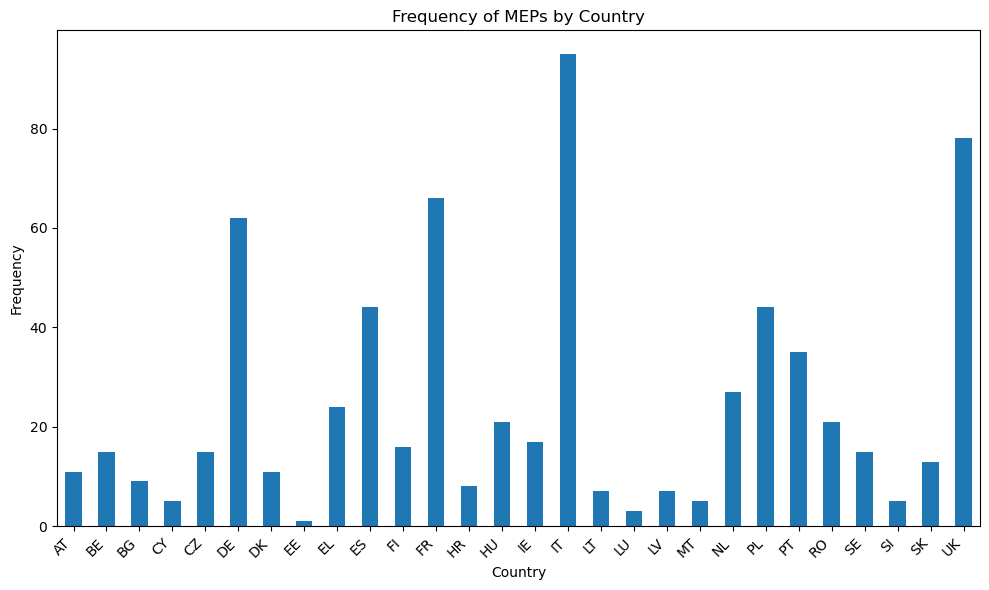

Frequency table for Frequency of MEPs by Party:
Party
ECR        104
EPP        239
G/EFA      104
GUE-NGL     89
ID          85
NI         126
Renew      145
S&D        194
Name: count, dtype: int64

----------------------------------------



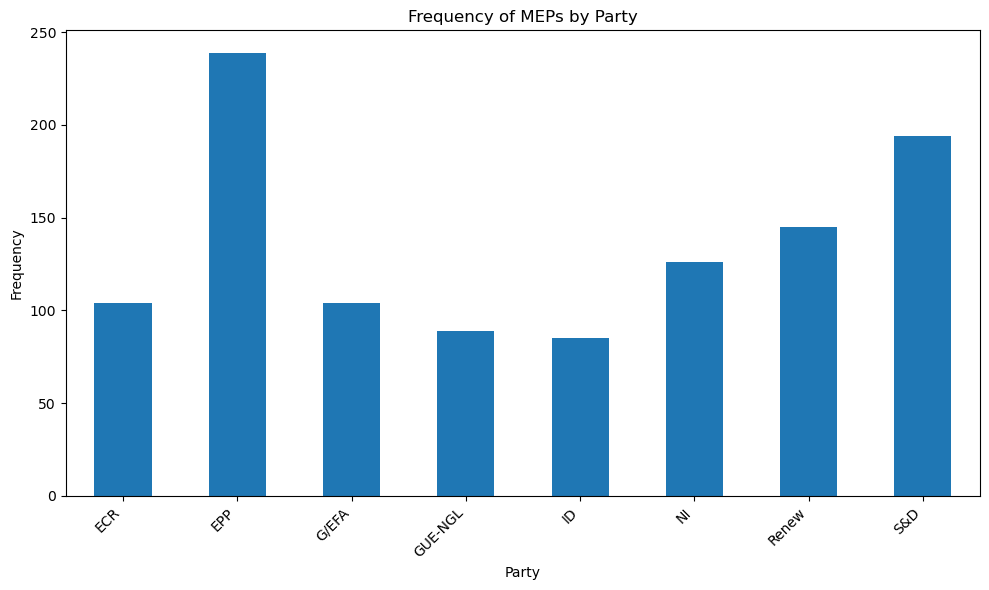

Graphs have been saved as 'country_frequency.png' and 'party_frequency.png'.


In [10]:
#Tests results
import pandas as pd
import matplotlib.pyplot as plt

# File path to the CSV file
csv_file_path = 

# Read the CSV file into a DataFrame
df = pd.read_csv(csv_file_path)

# Function to plot frequency bar graphs and print frequency tables
def plot_and_print_frequency(data, title, xlabel, ylabel, output_file):
    # Calculate frequency table
    frequency_table = data.value_counts().sort_index()

    # Print the frequency table
    print(f"Frequency table for {title}:")
    print(frequency_table)
    print("\n" + "-"*40 + "\n")

    # Plot the frequency bar graph
    plt.figure(figsize=(10, 6))
    frequency_table.plot(kind='bar')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()

# Plot the frequency bar graph and print the table for 'Country'
plot_and_print_frequency(df['Country'], 'Frequency of MEPs by Country', 'Country', 'Frequency', 'country_frequency.png')

# Plot the frequency bar graph and print the table for 'Party'
plot_and_print_frequency(df['Party'], 'Frequency of MEPs by Party', 'Party', 'Frequency', 'party_frequency.png')

print("Graphs have been saved as 'country_frequency.png' and 'party_frequency.png'.")


In [11]:
#Tests results
import pandas as pd

# Path to the CSV file
file_path = 

# Load the CSV file
df = pd.read_csv(file_path)

# Drop duplicate names, keeping only unique ones
unique_names = df['Name'].drop_duplicates()

# Count the number of unique names
unique_name_count = unique_names.count()

# Print the result
print(f"Number of unique names: {unique_name_count}")


Number of unique names: 873
